In [2]:
from datastructures.graph import load_pair, load_res,load_x, MatSurfGraph
from neural_models.gcn import MatSurfGcn, GorynychConv
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import json
import numpy as np
import pandas as pd

In [3]:
SAVE_DIR = "/home/nikita/PycharmProjects/OpenMC/neuro/models/v7/GorynychGCN"
BASE_DIR = "/run/media/nikita/e40c1d03-27f0-4c5f-b778-1710c9a842d0/data/server_sync/data/v7/"

K_MIN = 0.2526038758680176
K_MAX = 1.4825291427183294

In [192]:

def norm_k(k):
    return float(((k-K_MIN)/(K_MAX-K_MIN)-0.5)*2)

def denorm_k(k):
    return float((k/2+0.5)*(K_MAX-K_MIN)+K_MIN)

def norm_graph(graph:MatSurfGraph) -> MatSurfGraph:
    for key, mat in graph.materials.items():
        nucs, vol, dens = mat[:-2], mat[-2], mat[-1]
        vol /= graph.total_volume
        
        exps = np.exp(nucs)
        nucs = exps/exps.sum()

        graph.materials[key] = nucs.tolist() + [vol, dens]

    return graph

def norm_power(P:float) -> float:
    return P/10_000

def norm_x(graph: MatSurfGraph, power: float) -> (MatSurfGraph, float): 
    return norm_graph(graph=graph), norm_power(P=power)

def pair_loader(dirs:list[str]):
    for _dir in dirs:
        yield load_pair(folder=_dir)

In [193]:
data_dirs = list(filter(lambda x: os.path.isdir(os.path.join(BASE_DIR, x)),  os.listdir(BASE_DIR)[:-1]))
len(data_dirs)

575

In [194]:
graphs_powers = list(norm_x(*load_x(os.path.join(BASE_DIR, x))) for x in tqdm(data_dirs, desc='Loading graphs'))
graphs, powers = list((x[0] for x in graphs_powers)), pd.Series(list((x[1] for x in graphs_powers)))
keffs = list(norm_k(load_res(os.path.join(BASE_DIR, x, 'data.csv'))) for x in tqdm(data_dirs, desc='Loading y_train'))

Loading y_train: 100%|██████████| 575/575 [00:05<00:00, 105.70it/s]


In [195]:
for p in powers.unique():
    print(f"Total count for {p} value: ", len(powers[powers==p]))

Total count for 0.1 value:  143
Total count for 1.0 value:  144
Total count for 5.0 value:  144
Total count for 10.0 value:  144


In [196]:
WUs = pd.Series(g.WURelation for g in graphs)
WUs

0      3.622205
1      1.761470
2      3.622205
3      1.761470
4      3.622205
         ...   
570    6.258227
571    3.621131
572    3.622205
573    1.761470
574    3.622205
Length: 575, dtype: float64

In [197]:
for p in sorted(WUs.unique()):
    print(f"Total count for {p} value: ", len(WUs[WUs==p]))

Total count for 1.6967335769008025 value:  48
Total count for 1.7224218087048495 value:  48
Total count for 1.761470044097097 value:  47
Total count for 3.292013945598118 value:  48
Total count for 3.4101633253021726 value:  48
Total count for 3.621131014876837 value:  48
Total count for 3.622205066145647 value:  48
Total count for 4.655946745061506 value:  48
Total count for 6.258227134560154 value:  48
Total count for 7.963920117592259 value:  48
Total count for 8.377416789158602 value:  48
Total count for 13.546125183737905 value:  48


In [198]:
WUs.describe()

count    575.000000
mean       4.999603
std        3.373571
min        1.696734
25%        3.292014
50%        3.622205
75%        7.111074
max       13.546125
dtype: float64

In [199]:
def parse_graph(graph:MatSurfGraph)-> dict:
    gd = {}
    
    gd['total_volume'] = graph.total_volume
    for i, mat in enumerate(graph.materials.values(), start=1):
        gd[f"volume_{i}"]=mat[-2]/graph.total_volume
    gd['WU'] = graph.WURelation
    gd['LatType'] = graph.lattype
    for i, cyl in enumerate(graph.cylinders.values(), start=1):
        # print(cyl)
        gd[f'cyl_{i}_r'] = cyl[-1]
    for i, plane in enumerate(graph.planes.values(), start=1):
        A, B, C, D = plane
        dist = abs(D)* ((A**2+B**2+C**2)**(-0.5))
        size = 2* dist
        if size >=100:
            gd['size_vert'] = size
        else:
            gd['pitch'] = size
    gd['rel_dist'] = gd['pitch'] / (2*gd['cyl_2_r'])
    return gd

parse_graph(graphs[0])

{'total_volume': 1.8221463270014793,
 'volume_1': 0.08545403638017839,
 'volume_2': 0.3665827791339365,
 'volume_3': 0.5479631844858851,
 'WU': 3.622205066145647,
 'LatType': 'hex',
 'cyl_1_r': 0.49999999999999994,
 'cyl_2_r': 0.7,
 'pitch': 2.25,
 'size_vert': 380.0,
 'rel_dist': 1.6071428571428572}

In [115]:
df = pd.DataFrame(
    [parse_graph(g) for g in graphs]
)
df

,total_volume,volume_1,volume_2,volume_3,WU,LatType,cyl_1_r,cyl_2_r,pitch,size_vert,rel_dist
0,1.822146,0.085454,0.366583,0.547963,3.622205,hex,0.5,0.7,2.250000,380.0,1.607143
1,1.712390,0.128024,0.288771,0.583204,1.761470,sqr,0.5,0.7,1.709630,380.0,1.221164
2,1.822146,0.085454,0.366583,0.547963,3.622205,hex,0.5,0.7,2.250000,380.0,1.607143
3,1.712390,0.128024,0.288771,0.583204,1.761470,sqr,0.5,0.7,1.709630,380.0,1.221164
4,1.822146,0.085454,0.366583,0.547963,3.622205,hex,0.5,0.7,2.250000,380.0,1.607143
...,...,...,...,...,...,...,...,...,...,...,...
570,1.911541,0.059248,0.418133,0.522619,6.258227,hex,0.7,0.9,3.750000,380.0,2.083333
571,1.857883,0.086918,0.375337,0.537745,3.621131,sqr,0.7,0.9,2.849384,380.0,1.582991
572,1.822146,0.085454,0.366583,0.547963,3.622205,hex,0.5,0.7,2.250000,380.0,1.607143
573,1.712390,0.128024,0.288771,0.583204,1.761470,sqr,0.5,0.7,1.709630,380.0,1.221164


In [103]:
df['thick'] = df.cyl_2_r - df.cyl_1_r
df.head()

,total_volume,volume_1,volume_2,volume_3,WU,LatType,cyl_1_r,cyl_2_r,pitch,size_vert,rel_dist,thick
0,1916.715464,0.155710,0.564013,0.280278,3.622205,hex,0.5,0.7,2.25000,380.0,1.607143,0.2
1,1361.376674,0.219228,0.386163,0.394610,1.761470,sqr,0.5,0.7,1.70963,380.0,1.221164,0.2
2,1916.715464,0.155710,0.564013,0.280278,3.622205,hex,0.5,0.7,2.25000,380.0,1.607143,0.2
3,1361.376674,0.219228,0.386163,0.394610,1.761470,sqr,0.5,0.7,1.70963,380.0,1.221164,0.2
4,1916.715464,0.155710,0.564013,0.280278,3.622205,hex,0.5,0.7,2.25000,380.0,1.607143,0.2


In [104]:
df.describe()

,total_volume,volume_1,volume_2,volume_3,WU,cyl_1_r,cyl_2_r,pitch,size_vert,rel_dist,thick
count,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.000000,575.0,575.000000,5.750000e+02
mean,3443.615312,0.153487,0.595454,0.251059,4.999603,0.633565,0.833565,2.861733,380.0,1.743601,2.000000e-01
std,1253.541229,0.055815,0.138694,0.083993,3.373571,0.149227,0.149227,0.630754,0.0,0.408479,3.925231e-17
min,1361.376674,0.061177,0.386163,0.110118,1.696734,0.500000,0.700000,1.709630,380.0,1.221164,2.000000e-01
25%,2511.750264,0.103079,0.564013,0.172598,3.292014,0.500000,0.700000,2.279507,380.0,1.582991,2.000000e-01
50%,3499.019225,0.155710,0.584755,0.251801,3.622205,0.700000,0.900000,2.849384,380.0,1.666667,2.000000e-01
75%,4441.483928,0.174324,0.724323,0.280278,7.111074,0.700000,0.900000,3.375000,380.0,2.059304,2.000000e-01
max,5547.053262,0.241477,0.828706,0.394610,13.546125,0.900000,1.100000,3.750000,380.0,2.678571,2.000000e-01


In [89]:
(df.total_volume - (df.volume_1 + df.volume_2 + df.volume_3)).mean()

np.float64(3442.6153117904346)

<Axes: >

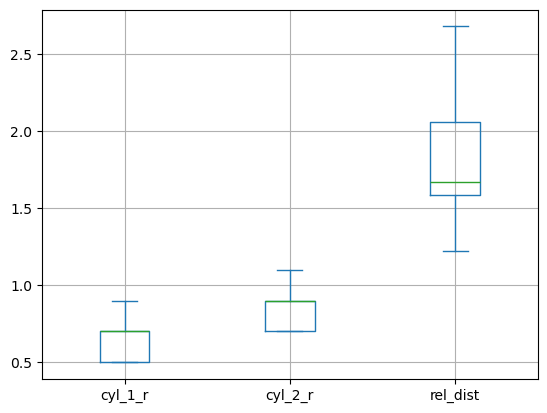

In [106]:
df[['cyl_1_r', 'cyl_2_r', 'rel_dist']].plot(kind='box', grid=True)

<Axes: >

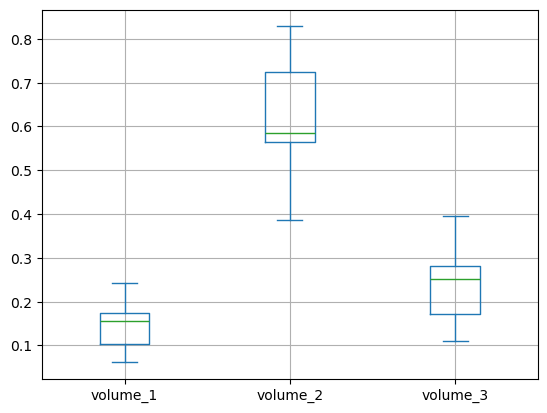

In [92]:
df[['volume_1', 'volume_2', 'volume_3']].plot(kind='box', grid=True)

<Axes: ylabel='Frequency'>

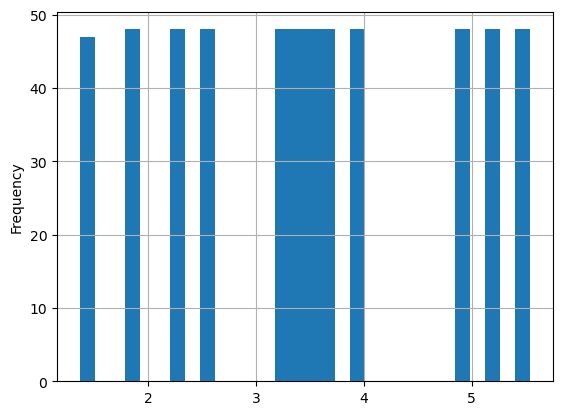

In [100]:
(df.total_volume/1000).plot(kind='hist', density=False, grid=True, bins=30)

<Axes: ylabel='Frequency'>

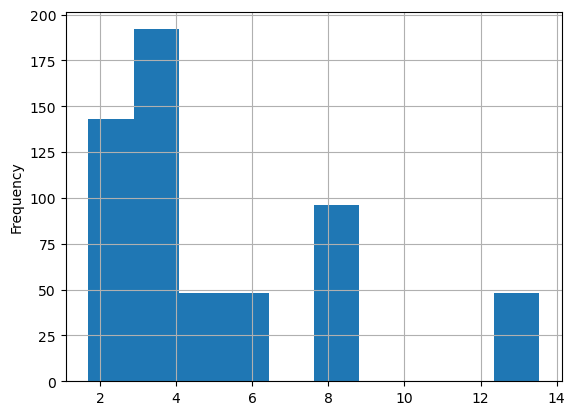

In [107]:
df.WU.plot(kind='hist', grid=True)

In [171]:
graphs[0].isotopes.index('U235'), graphs[0].isotopes.index('U238')

(33, 35)

In [178]:
for i, mat in graphs[0].materials.items():
    print(i, sum(mat[:-2]))

26 3.0
27 3.0
30 0.999999


In [166]:
test_mats =  np.array(graphs[0].materials['26'][:-2])
test_mats

array([0.00000000e+00, 0.00000000e+00, 1.99924200e+00, 7.58000000e-04,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       3.61911401e-04, 4.04906804e-02, 1.85466764e-04, 9.58961941e-01])

In [173]:
test_mats[33], test_mats[35],

(np.float64(0.04049068035500857), np.float64(0.9589619414796624))

In [180]:
logs = np.log10(test_mats)
logs1 = logs
logs1[logs1==-np.inf] = 0
logs1

/tmp/ipykernel_1164174/315627371.py:1: RuntimeWarning: divide by zero encountered in log10
  logs = np.log10(test_mats)


array([ 0.        ,  0.        ,  0.30086537, -3.12033079,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -3.44139774, -1.39264493, -3.7317339 ,
       -0.01819863])

In [179]:
pd.Series(logs[logs!=-np.inf]).describe()

count    36.000000
mean     -0.316762
std       0.984504
min      -3.731734
25%       0.000000
50%       0.000000
75%       0.000000
max       0.300865
dtype: float64

In [191]:
exps = np.exp(test_mats.tolist())
exps /= exps.sum()
exps

array([0.02270917, 0.02270917, 0.1676722 , 0.02272639, 0.02270917,
       0.02270917, 0.02270917, 0.02270917, 0.02270917, 0.02270917,
       0.02270917, 0.02270917, 0.02270917, 0.02270917, 0.02270917,
       0.02270917, 0.02270917, 0.02270917, 0.02270917, 0.02270917,
       0.02270917, 0.02270917, 0.02270917, 0.02270917, 0.02270917,
       0.02270917, 0.02270917, 0.02270917, 0.02270917, 0.02270917,
       0.02270917, 0.02270917, 0.02271739, 0.02364755, 0.02271338,
       0.05924793])